# 2nd Sept 2026 : Introduction to Linear Elasticity

Notes by: Vamshik M (26511)

This python notebook contains notes from 02nd September 2026 

I have blended the notes with typed text and handwritten notes as well, the code example is put at the end cleanly. 

## Q1. Scalars vs Vectors

Let's talk about what changes when we move from PDEs with scalar valued functions to vector valued functions.

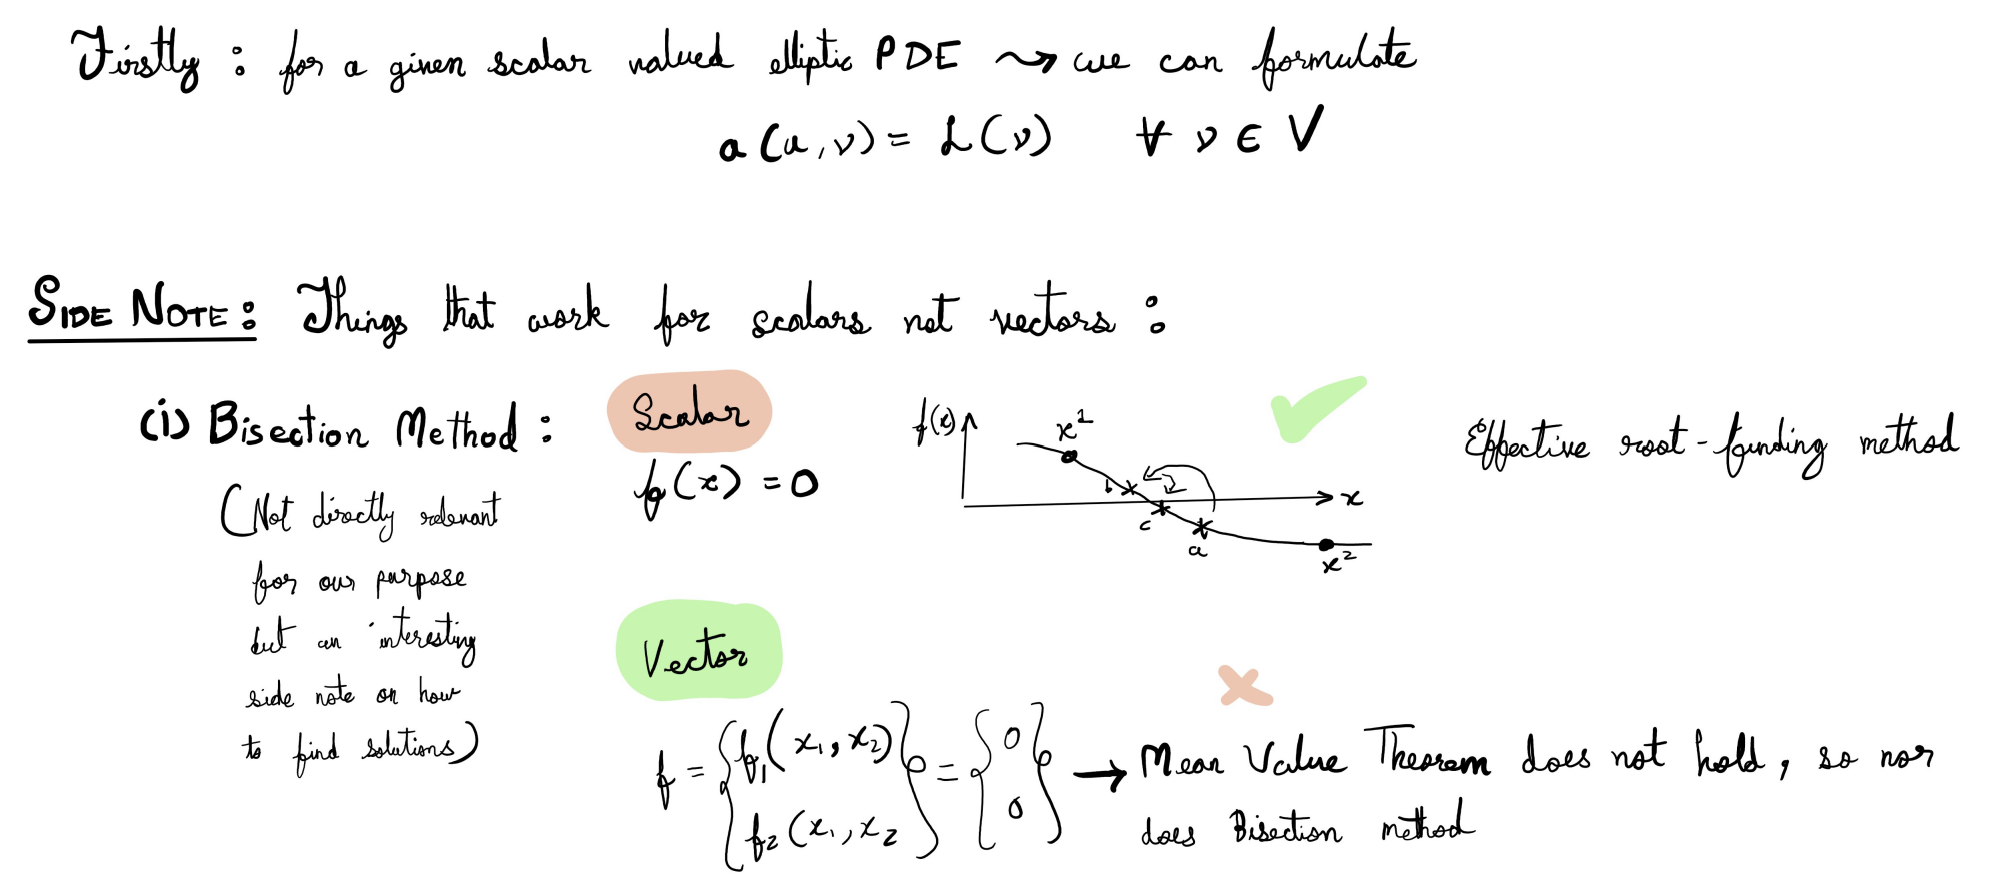

A key change is in constructing a compatibility relation

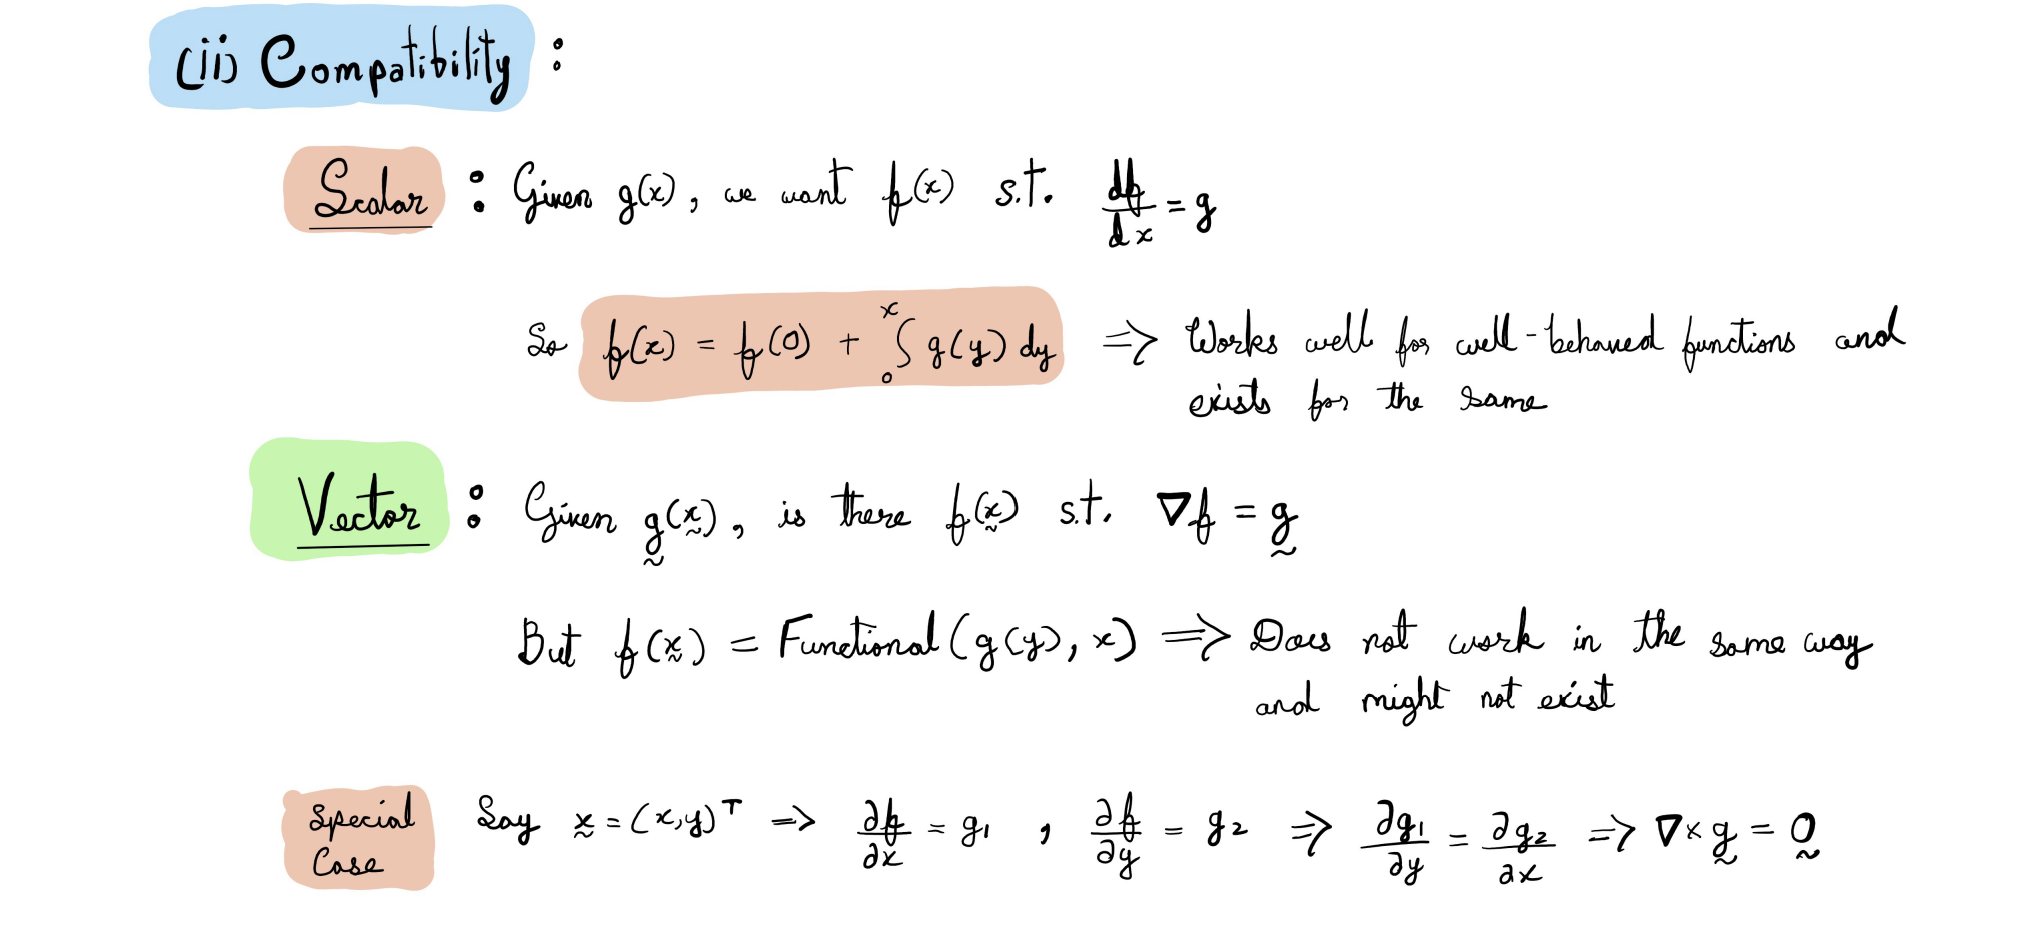


## Q2. Constitutive Relation

First, we state the Newton Force Balance relation as shown below (This comes from our Solid/Continuum Mechanics course if reference needed)

Note that I use double ~ under the letter for 2nd order tensors and a single ~ for vectors. But as defined in the note, I have not used it in the derivations for simplicity.

### Q2.1 Newton's Force Balance statement

Displacement Gradient is the best measure of change in physical dimension that can be related to a forcing.

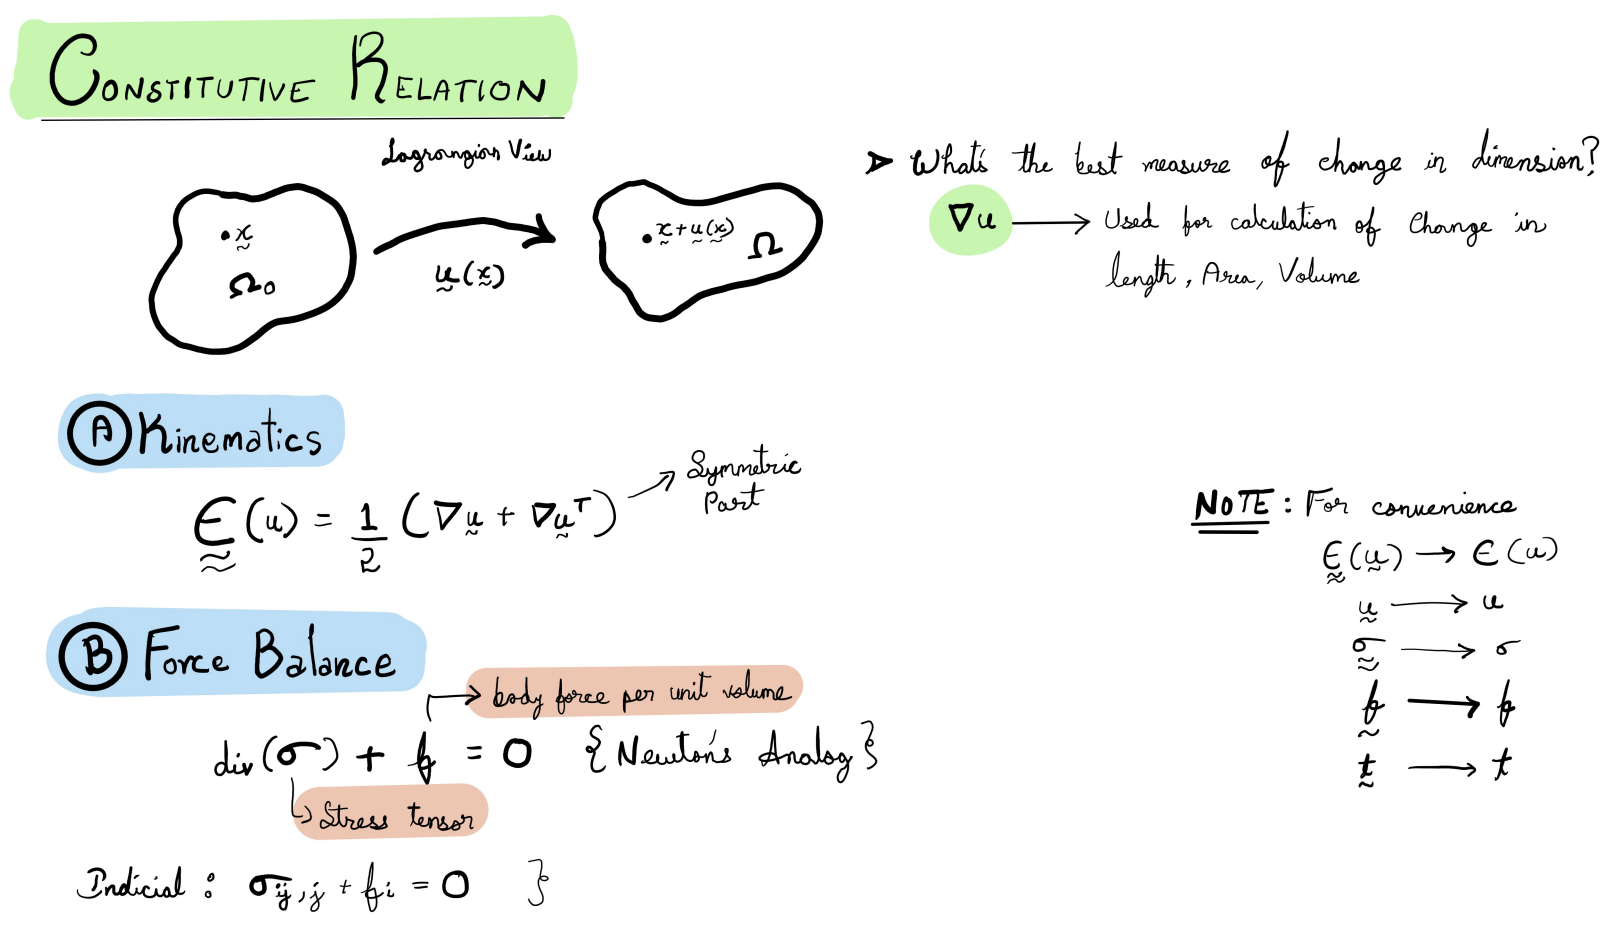

### Q2.2 Equivalence of Integral/Derivative forms

This is more of a show of integral form equivalence to pointwise derivative form of Newton's force balance formulation.

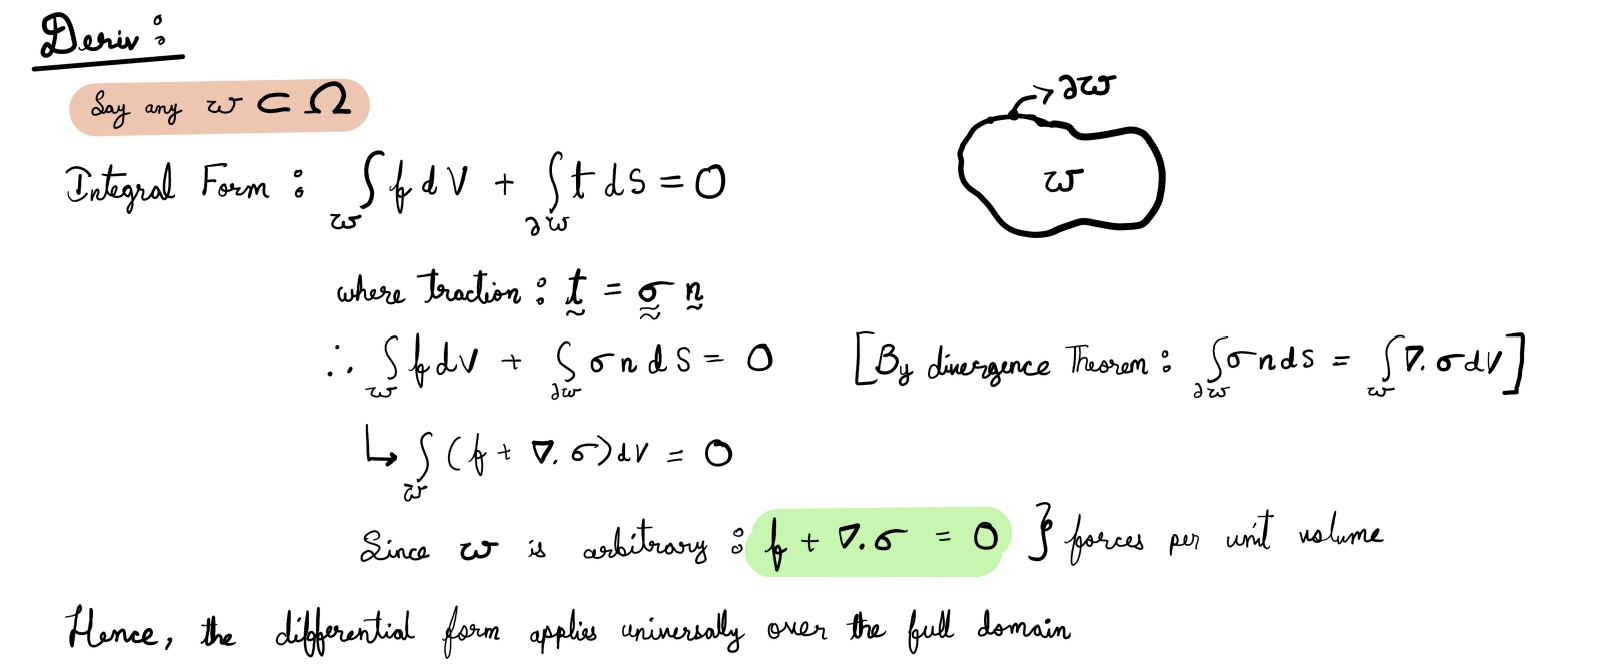


### Q2.3 Consitutive Relation statement

Here, I simply state the relation for reference before we talk more on its nuances. Lambda and Mu are called Lame's parameters.

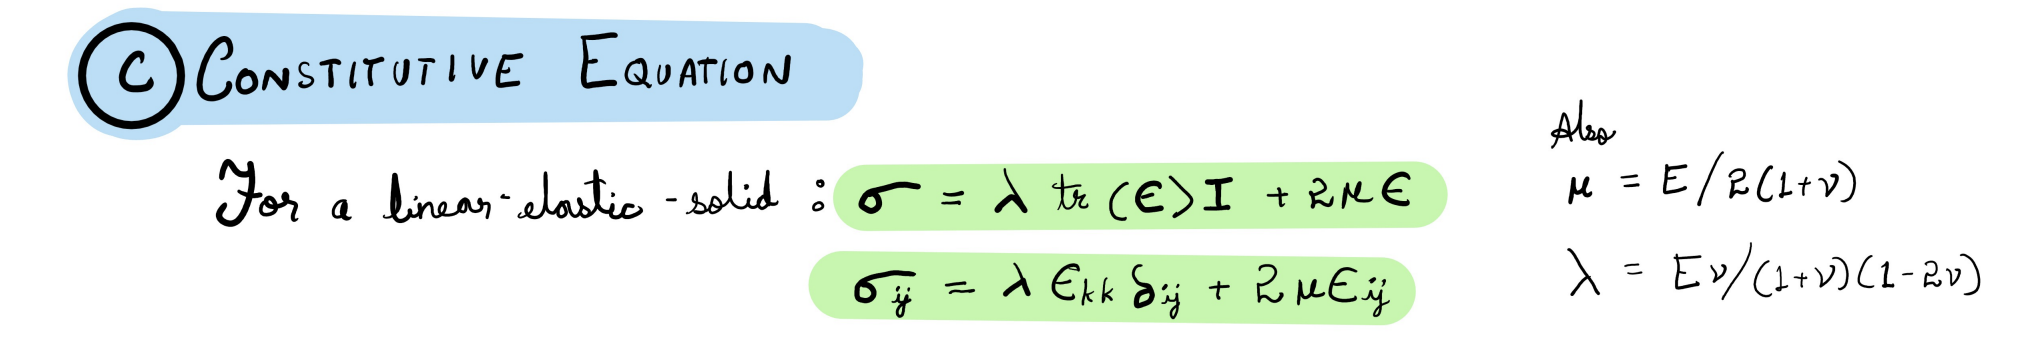

Observe in the above that this is simply a way to relate the stress of a Linearly Elastic material to its strain (Also check Solid Mechanics for more details on its origins)

### Q2.4 Methods to Solve Newton's Balance using the Constitutive Relation

There are many methods stated over a century, some we might be familiar include Airy Stress Function, Maxwell/Beltrami methods, an infinite fourier series approach.

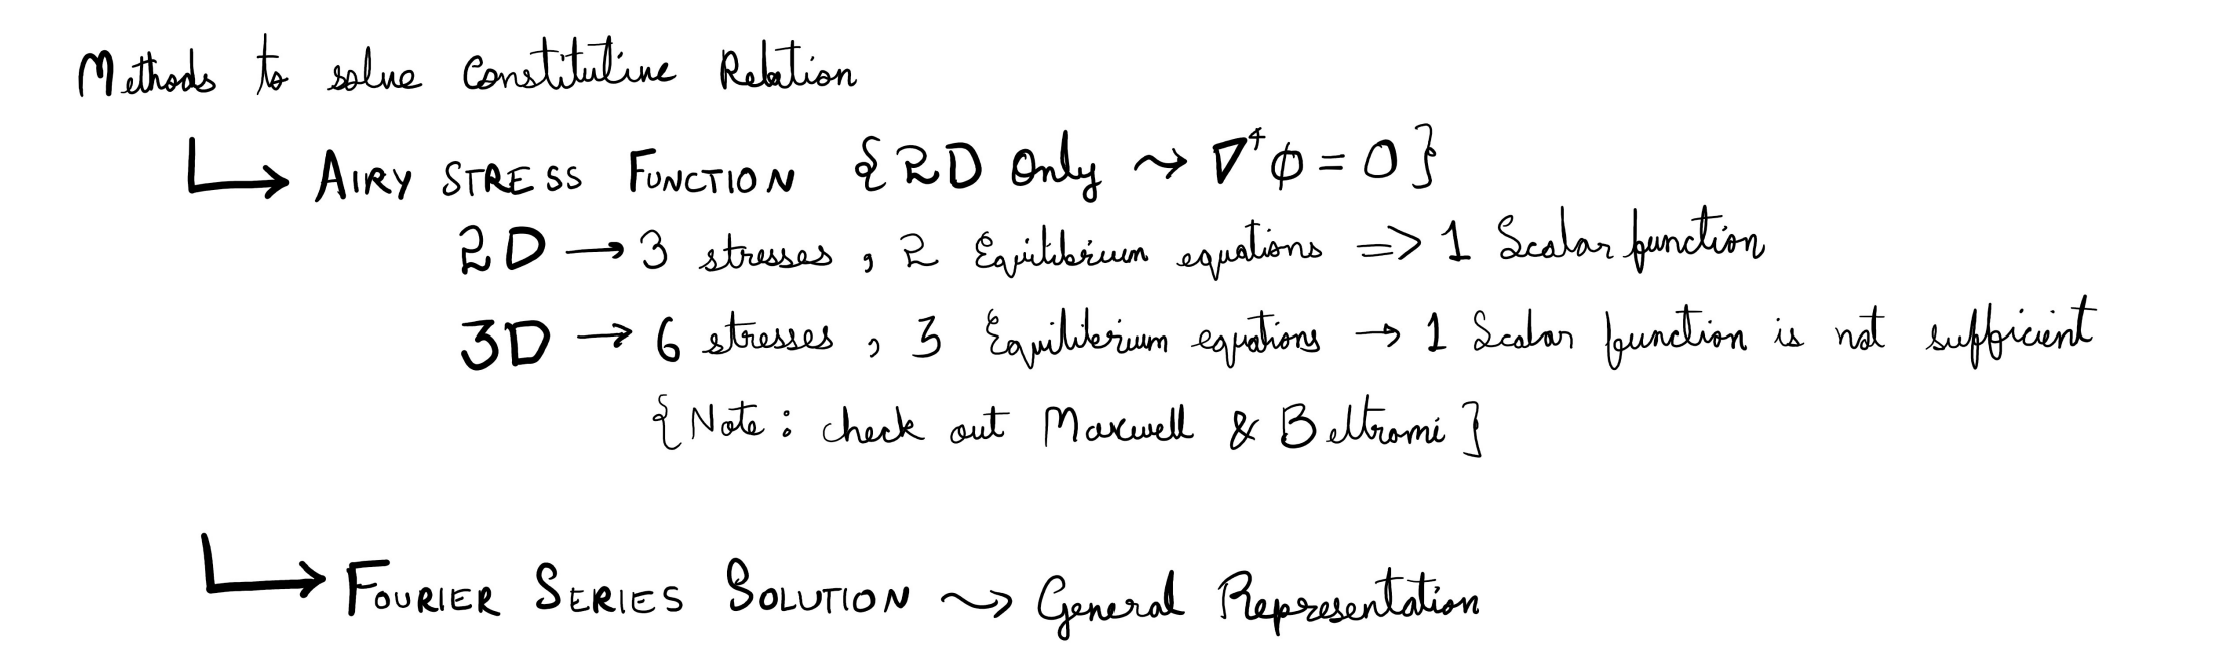

And now most importantly for us: the **Weak Form approach which we use for FEM.**

### Q2.5 Weak Form

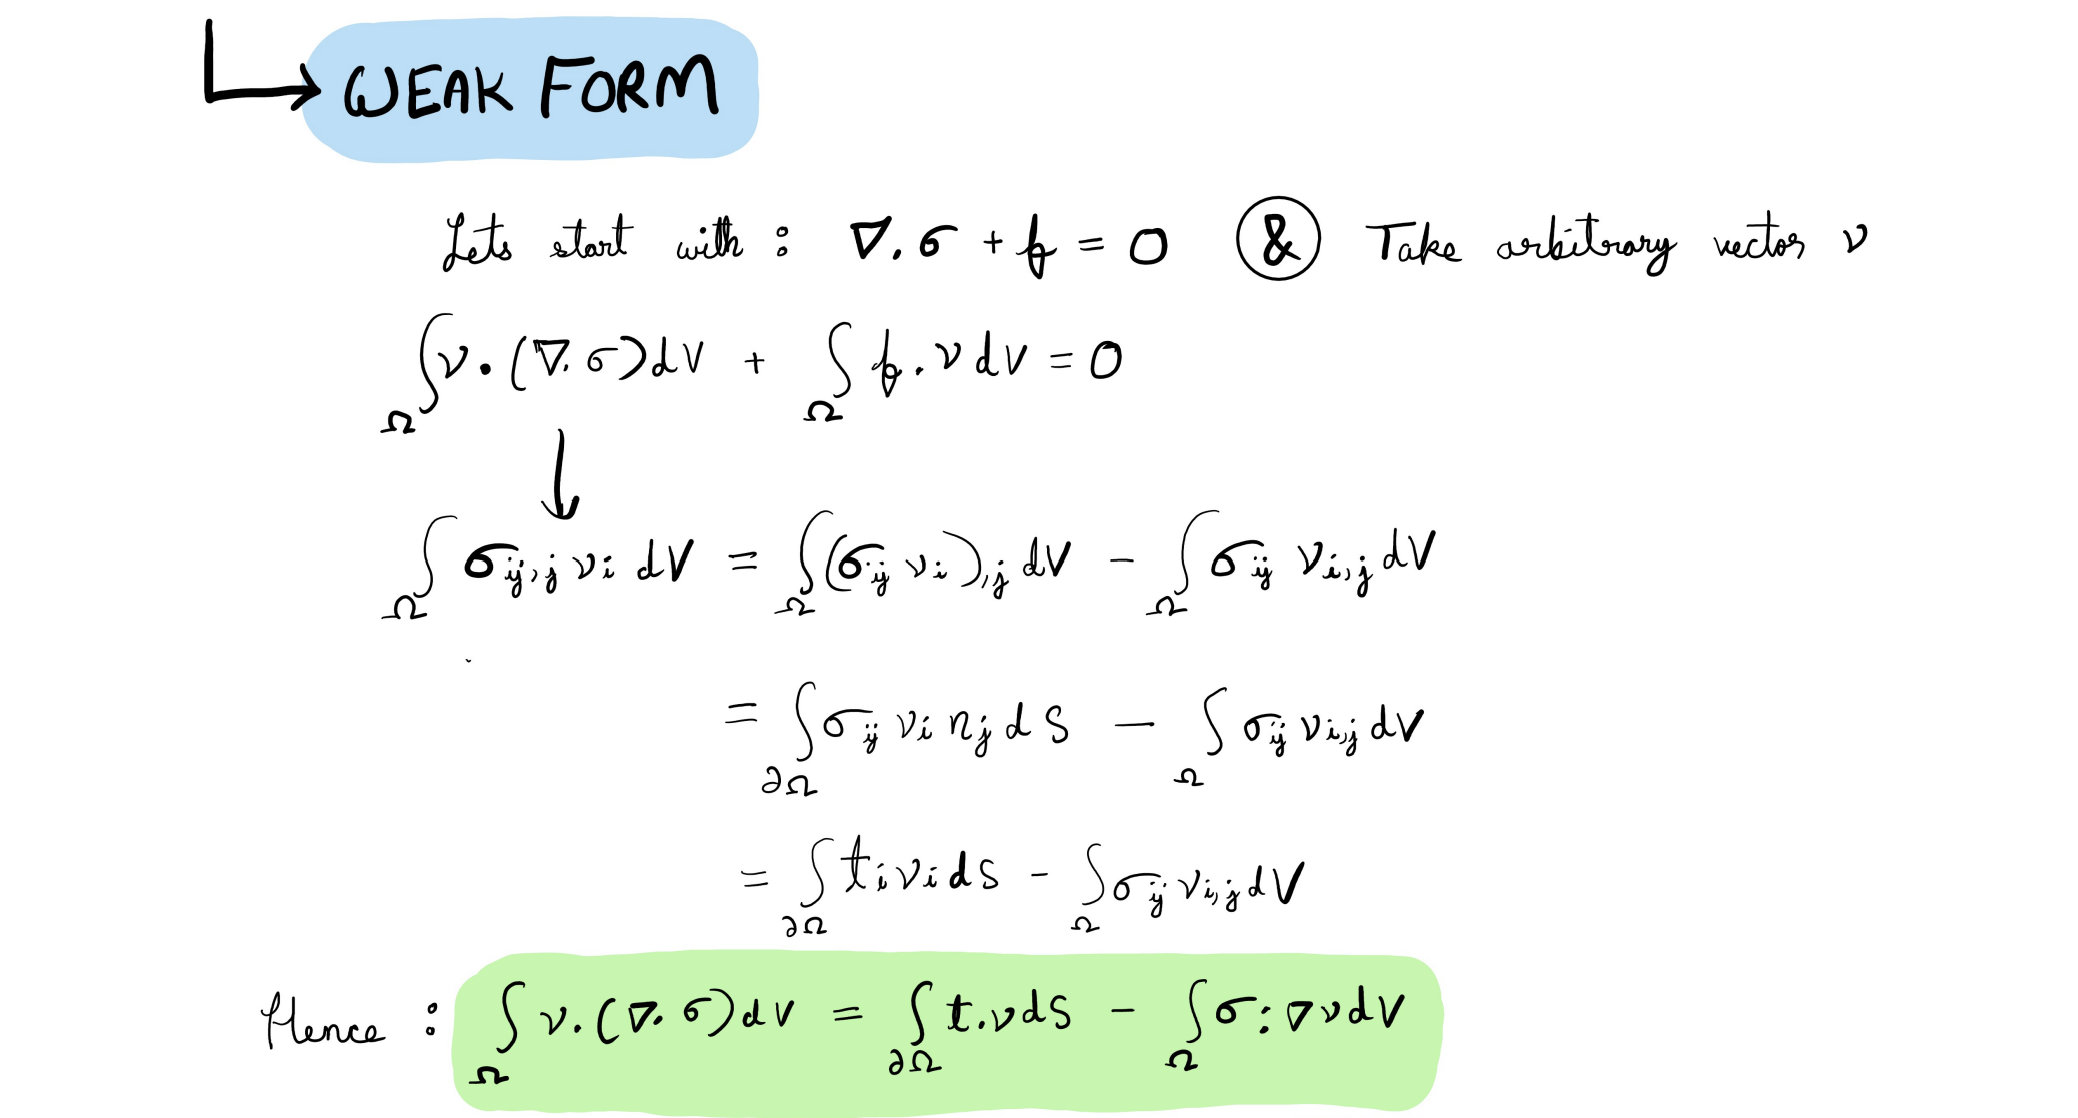

Then, we can put it together and bring in the idea of traction (useful way to incorporate Boundary Conditions). We can then simplify the expression after incorporating the BCs (Here, for simplicity: assume t=0).

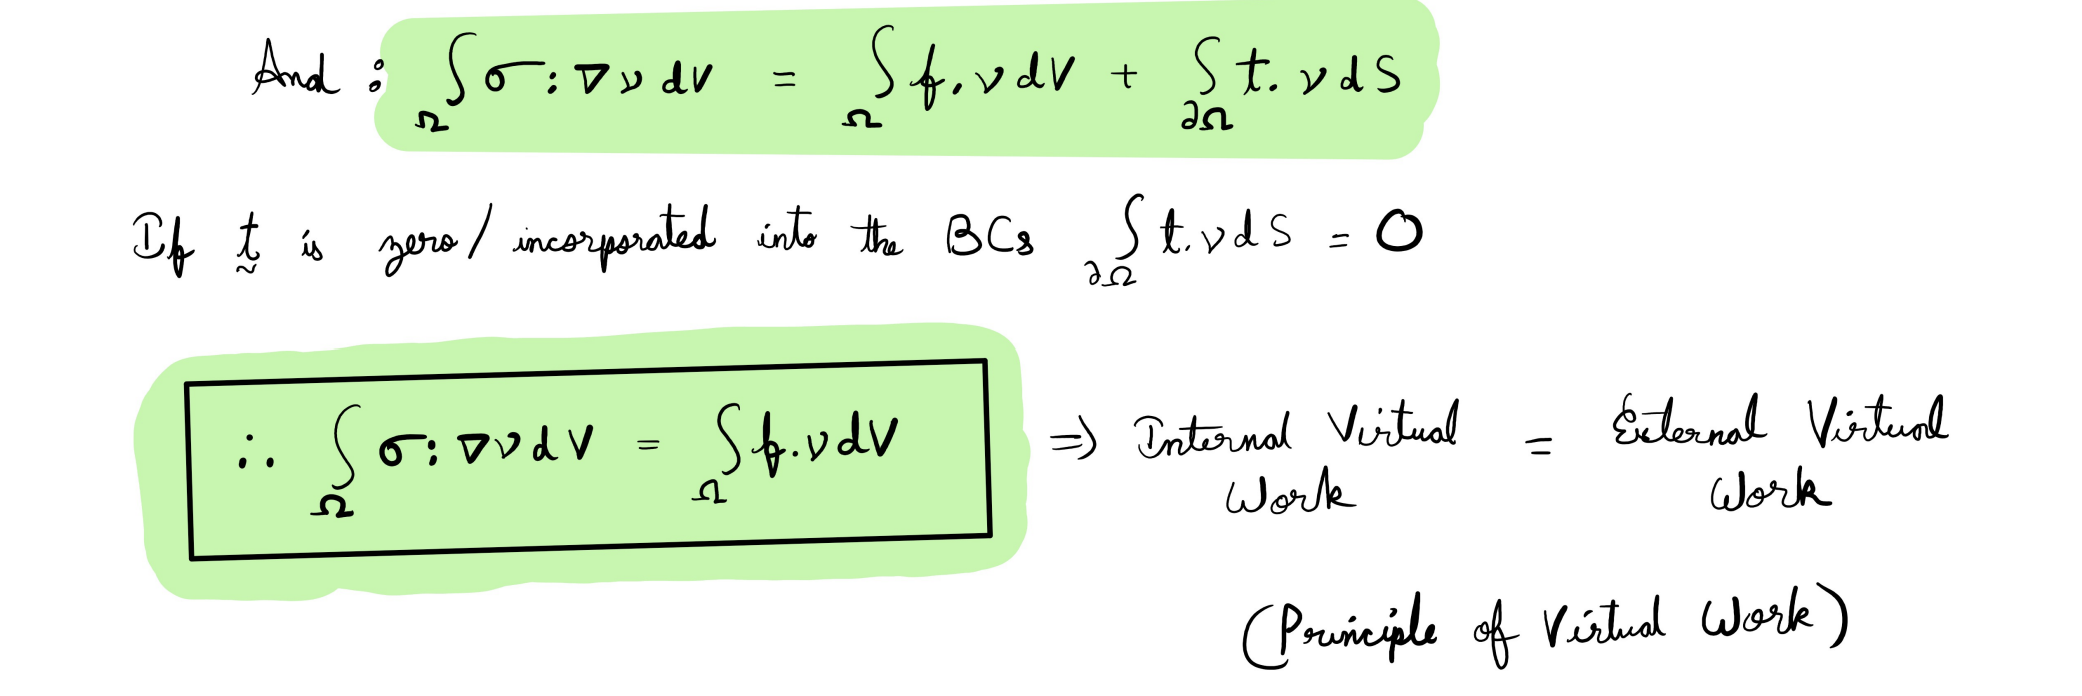

Best part, this is the exact same as the principle of virtual work.

### Q2.6 Bringing Strain Tensor directly

This is more so observing that only the symmetric part of the gradient is only necessary.

So finally:

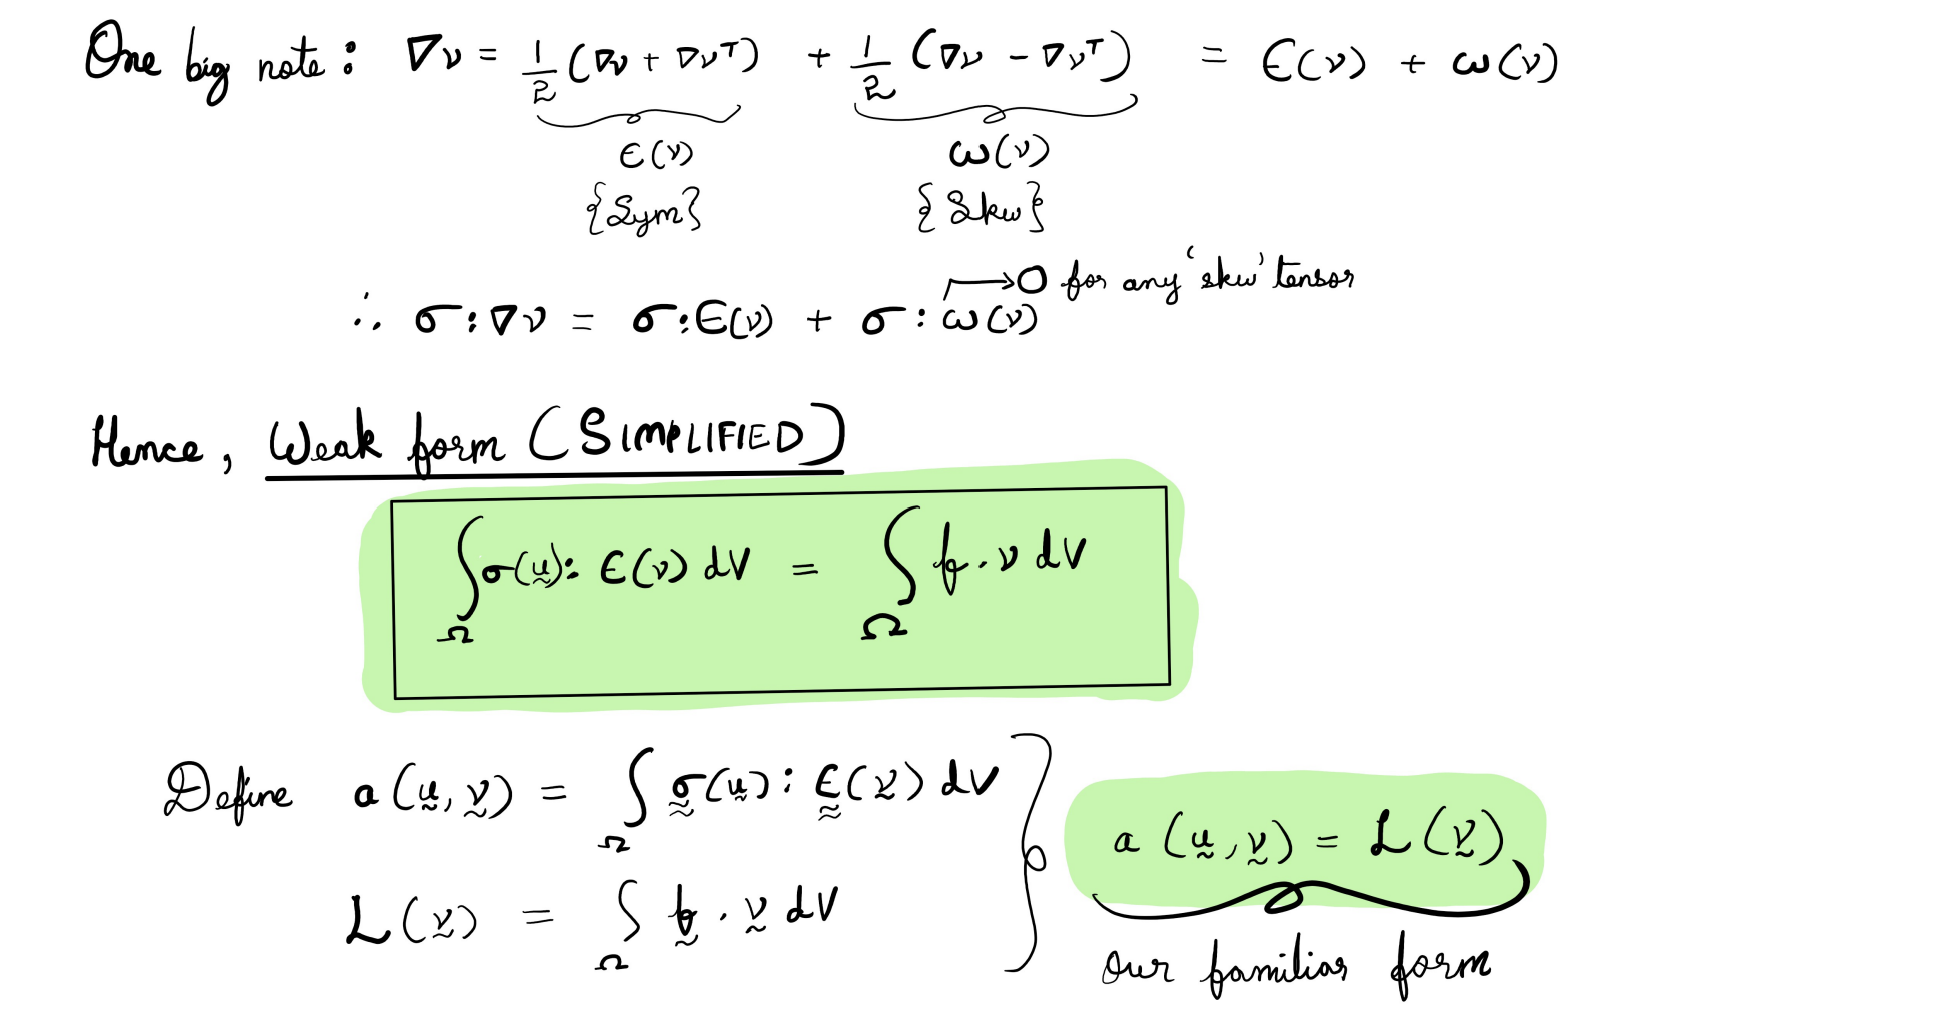


## Q3. 2D LINEAR ELASTICITY - MANUFACTURED SOLUTION CODE

Let's set up the same in Dolphinx now:

<u>**Governing equations:**</u>
   
   epsilon(u) = sym(grad(u))

   sigma(u) = lambda * tr(epsilon(u)) * I + 2 * mu * epsilon(u)
   div(sigma) + f = 0

<u>**Weak form:**</u>

   integral_Omega sigma(u) : epsilon(v) dx = integral_Omega f . v dx

   a(u,v) = L(v)

In [15]:

# Let's hand in all the necessary libraries

from mpi4py import MPI
from petsc4py.PETSc import ScalarType
import numpy as np
import ufl

from dolfinx import fem, io, mesh
from dolfinx.fem.petsc import LinearProblem


In [16]:
# 1. CREATE MESH, Function Space, Coordinates

msh = mesh.create_unit_square(
    MPI.COMM_WORLD,
    10,
    10
)

V = fem.functionspace(
    msh,
    ("Lagrange", 1, (2,))
)

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# Spatial coordinates
x = ufl.SpatialCoordinate(msh)


In [17]:
# 4. MATERIAL PROPERTIES
# We define some arbitrary material properties for the problem and derive the Lame parameters from them. 

E = 1.0
nu = 0.3

mu = E / (2.0 * (1.0 + nu))

lmbda = (
    E * nu
    / ((1.0 + nu) * (1.0 - 2.0 * nu))
)

In [18]:
# Let's define a fucntion to compure strain and stress tensors

def epsilon(w):
    return ufl.sym(ufl.grad(w)) # Yeah, you can return ufl functions directly

def sigma(w):
    eps = epsilon(w)
    return (
        lmbda * ufl.tr(eps) * ufl.Identity(2)
        + 2.0 * mu * eps
    )

In [19]:
# Exact Solution so we can manufacture a force and compare the numerical solution to it.


ue = ufl.as_vector((
    ufl.cos(ufl.pi * x[0]) * ufl.cos(ufl.pi * x[1]),
    ufl.sin(ufl.pi * x[0]) * ufl.sin(ufl.pi * x[1])
))
# So we have a body force like so:

f = -ufl.div(sigma(ue))

In [20]:
# Now let's make a weak form

a = (
    ufl.inner(
        sigma(u),
        epsilon(v)
    )
    * ufl.dx
)

L = (
    ufl.dot(f, v)
    * ufl.dx
)


In [21]:
# Let's apply Boundary COnditions

tdim = msh.topology.dim # Chat GPT added this on
print(tdim) # Should come to 2 for a 2D mesh
fdim = tdim - 1

facets = mesh.locate_entities_boundary(
    msh,
    msh.topology.dim - 1,
    marker=lambda x: np.full(x.shape[1], True)
)


dofs = fem.locate_dofs_topological(
    V,
    msh.topology.dim - 1,
    facets
)


2


In [22]:
# Interpolate the exact solution to the function space 

ue_expr = fem.Expression(
    ue,
    V.element.interpolation_points
)

u_bc = fem.Function(V)

u_bc.interpolate(ue_expr)

bc = fem.dirichletbc(u_bc, dofs)

In [23]:
# Solve

problem = LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu"
    },
    petsc_options_prefix="elasticity"

)

uh = problem.solve()

uh.name = "displacement" #For Paraview stuff

#Quick Check
print("uh name:", uh.name)
print("uh size:", uh.x.array.size)
print("uh min:", uh.x.array.min())
print("uh max:", uh.x.array.max())

uh name: displacement
uh size: 242
uh min: -1.0
uh max: 1.0


In [24]:
# Direct Method

# with io.VTKFile(
#     MPI.COMM_WORLD,
#     "elasticity.pvd",
#     "w"
# ) as vtk:

#     vtk.write_mesh(msh)
#     vtk.write_function(uh)

In [25]:
# I wanted to put the files in a subfolder

from pathlib import Path

output_dir = Path("results")
output_dir.mkdir(parents=True, exist_ok=True)

with io.VTKFile(
    MPI.COMM_WORLD,
    str(output_dir / "elasticity.pvd"),
    "w"
) as vtk:

    vtk.write_mesh(msh)
    vtk.write_function(uh)

## Q4. Plotting in Paraview

The "vtk.write_function(uh)" puts the solution function form and its coefficients into a set of files and a wrapper file named elasticity.pvd

It makes a bunch of pvtu and vtu files (GPT them for more info if necessary)

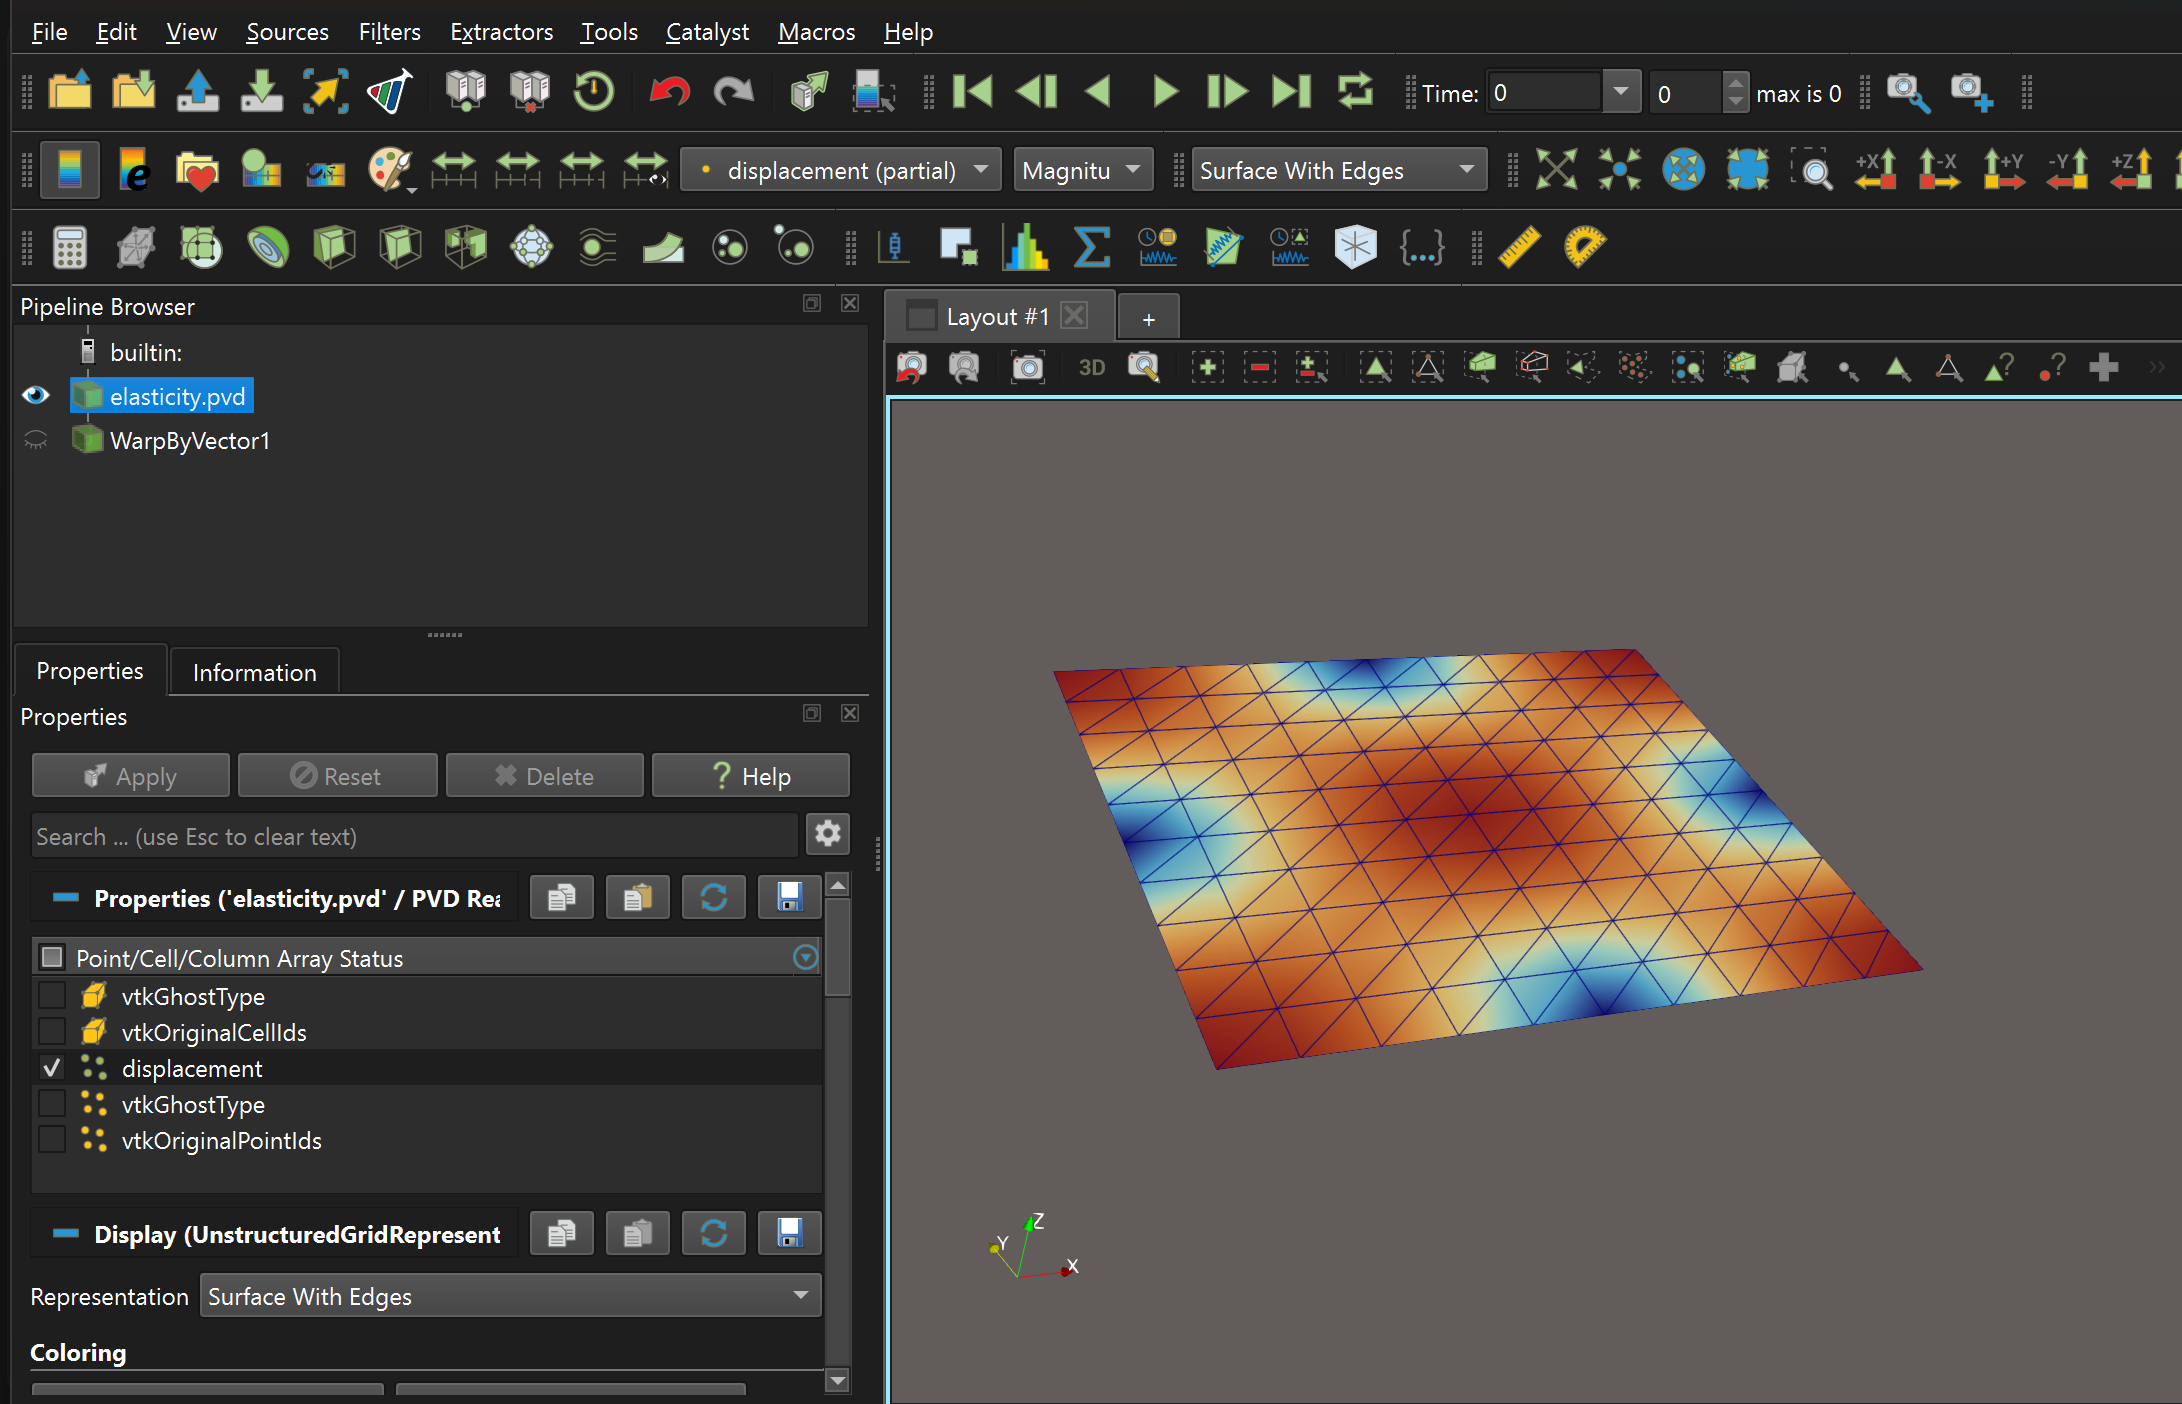

use warp_by_vector and other visualization features for understanding it better.


### Paraview Tutorial Video

1. I found this tutorial for paraview which seemed very relevant (It's from IIT Kanpur, go check it out)

How to Visualize Finite Element Results in ParaView (Complete Guide): Numerically_Stable
https://youtu.be/lCPQ8cbZ6JQ

2. Official Documentation: https://docs.paraview.org/en/latest/Tutorials/SelfDirectedTutorial/index.html